# GAF-Net: Enhanced Potato Leaf Disease Detection (YOLOv8-based)

Implementation using the Potato Disease Leaf Dataset (PLD).

**Classes:** Early Blight, Late Blight, Healthy

**Key Components:** GSConv, FASFF, Small Target Detection Head, YOLOv8 backbone

In [1]:
# Cell 1: Install dependencies
!pip install -q kagglehub torch torchvision matplotlib seaborn scikit-learn tqdm pillow

In [2]:
# Cell 2: Imports
import os, random, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from PIL import Image
from collections import Counter
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [3]:
# Cell 3: Download dataset
import kagglehub
dataset_path = kagglehub.dataset_download("rizwan123456789/potato-disease-leaf-datasetpld")
print(f"Dataset downloaded to: {dataset_path}")
for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 3:
        for f in files[:3]: print(f"{indent}  {f}")
        if len(files) > 3: print(f"{indent}  ... and {len(files)-3} more")

Dataset downloaded to: /kaggle/input/datasets/rizwan123456789/potato-disease-leaf-datasetpld
potato-disease-leaf-datasetpld/
  PLD_3_Classes_256/
    Validation/
      Late_Blight/
      Early_Blight/
      Healthy/
    Training/
      Late_Blight/
      Early_Blight/
      Healthy/
    Testing/
      Late_Blight/
      Early_Blight/
      Healthy/


In [4]:
# Cell 4: Locate directories and collect images
CLASS_NAMES = ['Early_Blight', 'Late_Blight', 'Healthy']
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}
NUM_CLASSES = len(CLASS_NAMES)

pld_root = None
for root, dirs, _ in os.walk(dataset_path):
    if 'PLD_3_Classes_256' in dirs:
        pld_root = os.path.join(root, 'PLD_3_Classes_256'); break
if pld_root is None:
    for root, dirs, _ in os.walk(dataset_path):
        if 'Training' in dirs and 'Validation' in dirs:
            pld_root = root; break
print(f"PLD root: {pld_root}")

def collect_images(split_dir):
    paths, labels = [], []
    for cls in CLASS_NAMES:
        d = os.path.join(split_dir, cls)
        if not os.path.isdir(d): print(f"  WARNING: {d} not found!"); continue
        imgs = [os.path.join(d,f) for f in os.listdir(d) if f.lower().endswith(('.jpg','.jpeg','.png','.bmp'))]
        paths.extend(imgs); labels.extend([CLASS_TO_IDX[cls]]*len(imgs))
        print(f"  {cls}: {len(imgs)} images")
    return paths, labels

print('\n--- Training ---')
train_paths, train_labels = collect_images(os.path.join(pld_root, 'Training'))
print('\n--- Validation ---')
val_paths, val_labels = collect_images(os.path.join(pld_root, 'Validation'))
print('\n--- Testing ---')
test_paths, test_labels = collect_images(os.path.join(pld_root, 'Testing'))
print(f"\nTrain: {len(train_paths)} | Val: {len(val_paths)} | Test: {len(test_paths)}")

PLD root: /kaggle/input/datasets/rizwan123456789/potato-disease-leaf-datasetpld/PLD_3_Classes_256

--- Training ---
  Early_Blight: 1303 images
  Late_Blight: 1132 images
  Healthy: 816 images

--- Validation ---
  Early_Blight: 163 images
  Late_Blight: 151 images
  Healthy: 102 images

--- Testing ---
  Early_Blight: 162 images
  Late_Blight: 141 images
  Healthy: 102 images

Train: 3251 | Val: 416 | Test: 405


In [5]:
# Cell 5: Class distribution
print('Train:', Counter(train_labels))
print('Val:  ', Counter(val_labels))
print('Test: ', Counter(test_labels))

Train: Counter({0: 1303, 1: 1132, 2: 816})
Val:   Counter({0: 163, 1: 151, 2: 102})
Test:  Counter({0: 162, 1: 141, 2: 102})


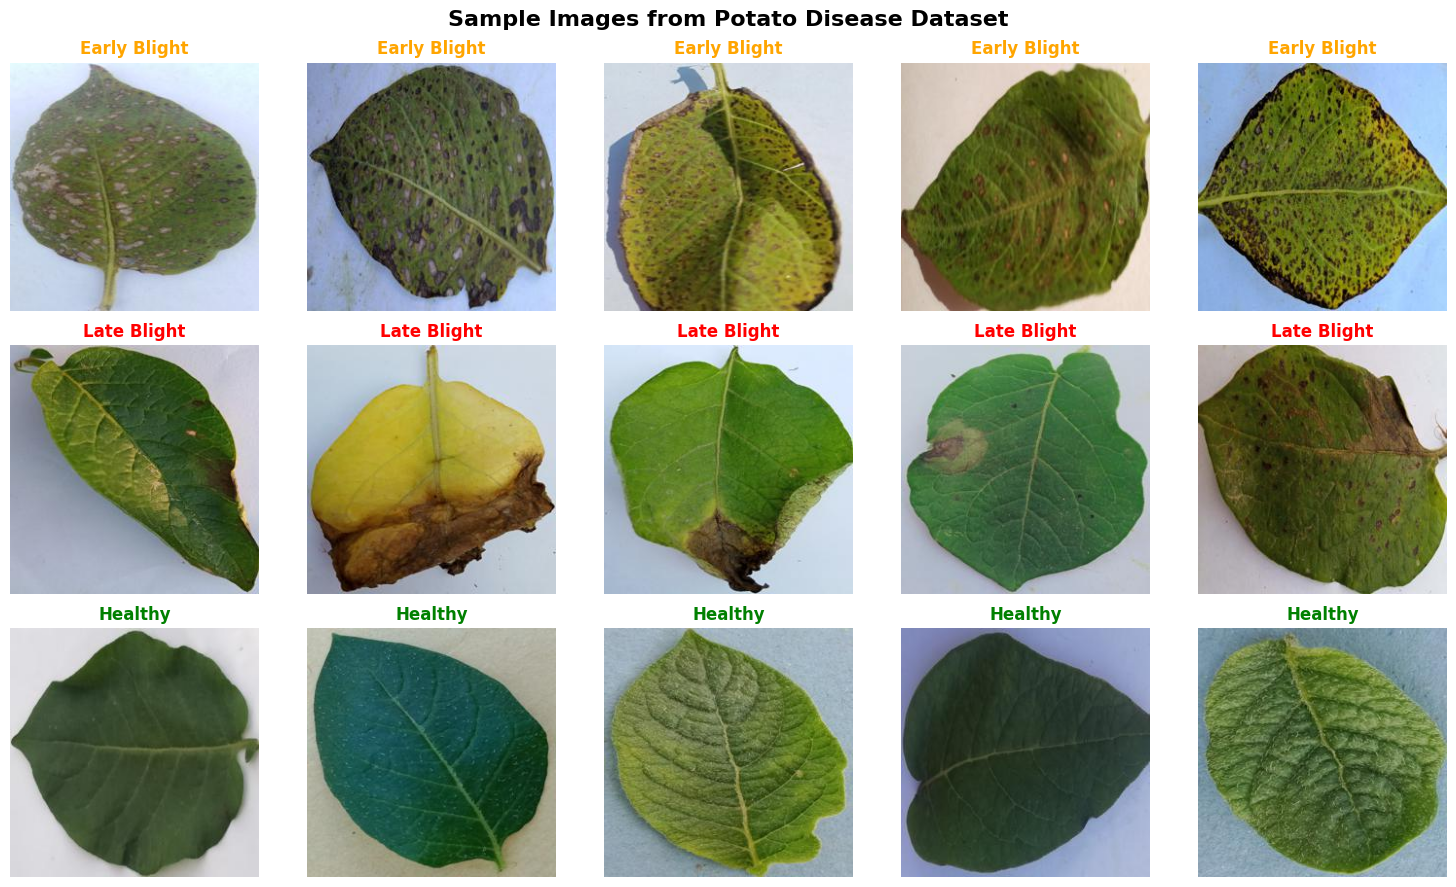

In [6]:
# Cell 6: Visualize samples
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
fig.suptitle('Sample Images from Potato Disease Dataset', fontsize=16, fontweight='bold')
colors = ['orange', 'red', 'green']
for row, cls in enumerate(CLASS_NAMES):
    d = os.path.join(pld_root, 'Training', cls)
    imgs = [os.path.join(d,f) for f in os.listdir(d) if f.lower().endswith(('.jpg','.jpeg','.png','.bmp'))][:5]
    for col, p in enumerate(imgs):
        axes[row,col].imshow(Image.open(p).convert('RGB'))
        axes[row,col].set_title(cls.replace('_',' '), color=colors[row], fontweight='bold')
        axes[row,col].axis('off')
plt.tight_layout(); plt.show()

In [7]:
# Cell 7: Dataset class
IMG_SIZE = 224
train_transform = transforms.Compose([transforms.Resize((IMG_SIZE,IMG_SIZE)),transforms.RandomHorizontalFlip(),transforms.RandomVerticalFlip(),transforms.RandomRotation(15),transforms.ColorJitter(brightness=0.2,contrast=0.2,saturation=0.2),transforms.ToTensor(),transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])
val_transform = transforms.Compose([transforms.Resize((IMG_SIZE,IMG_SIZE)),transforms.ToTensor(),transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])

class PotatoLeafDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
    def __len__(self): return len(self.image_paths)
    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        label = self.labels[idx]
        if self.transform: img = self.transform(img)
        return img, label

In [8]:
# Cell 8: DataLoaders
BATCH_SIZE = 32
train_ds = PotatoLeafDataset(train_paths, train_labels, train_transform)
val_ds   = PotatoLeafDataset(val_paths,   val_labels,   val_transform)
test_ds  = PotatoLeafDataset(test_paths,  test_labels,  val_transform)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

Train: 3251 | Val: 416 | Test: 405


In [9]:
# Cell 9: GSConv Module
class GSConv(nn.Module):
    """Grouped Spatial Convolution"""
    def __init__(self, c1, c2, k=3, s=1, act=True):
        super().__init__()
        c_ = c2 // 2
        self.conv = nn.Sequential(nn.Conv2d(c1, c_, k, s, k//2, bias=False), nn.BatchNorm2d(c_), nn.SiLU(inplace=True) if act else nn.Identity())
        self.dw_conv = nn.Sequential(nn.Conv2d(c_, c_, k, 1, k//2, groups=c_, bias=False), nn.BatchNorm2d(c_), nn.SiLU(inplace=True) if act else nn.Identity())
    def forward(self, x):
        x1 = self.conv(x); x2 = self.dw_conv(x1)
        out = torch.cat([x1, x2], dim=1)
        b, c, h, w = out.shape
        out = out.view(b, 2, c//2, h, w).transpose(1, 2).contiguous().view(b, c, h, w)
        return out
print('GSConv defined.')

GSConv defined.


In [10]:
# Cell 10: FASFF Module
class FASFF(nn.Module):
    """Feature-Adaptive Spatial Feature Fusion"""
    def __init__(self, channels, level=0):
        super().__init__()
        self.weight1 = nn.Conv2d(channels, 1, 1, bias=True)
        self.weight2 = nn.Conv2d(channels, 1, 1, bias=True)
        self.weight3 = nn.Conv2d(channels, 1, 1, bias=True)
        self.align1 = nn.Sequential(nn.Conv2d(channels, channels, 1, bias=False), nn.BatchNorm2d(channels))
        self.align2 = nn.Sequential(nn.Conv2d(channels, channels, 1, bias=False), nn.BatchNorm2d(channels))
        self.align3 = nn.Sequential(nn.Conv2d(channels, channels, 1, bias=False), nn.BatchNorm2d(channels))
    def forward(self, feats):
        f1, f2, f3 = feats
        target_size = f1.shape[2:]
        f2_r = F.interpolate(f2, size=target_size, mode='bilinear', align_corners=False)
        f3_r = F.interpolate(f3, size=target_size, mode='bilinear', align_corners=False)
        f1, f2_r, f3_r = self.align1(f1), self.align2(f2_r), self.align3(f3_r)
        w = torch.softmax(torch.cat([self.weight1(f1), self.weight2(f2_r), self.weight3(f3_r)], dim=1), dim=1)
        return f1*w[:,0:1] + f2_r*w[:,1:2] + f3_r*w[:,2:3]
print('FASFF defined.')

FASFF defined.


In [11]:
# Cell 11: GAF-Net Architecture
class ConvBlock(nn.Module):
    def __init__(self, c1, c2, k=3, s=1, p=1):
        super().__init__()
        self.conv = nn.Conv2d(c1, c2, k, s, p, bias=False)
        self.bn = nn.BatchNorm2d(c2)
        self.act = nn.SiLU(inplace=True)
    def forward(self, x): return self.act(self.bn(self.conv(x)))

class C2fBlock(nn.Module):
    def __init__(self, c1, c2, n=1):
        super().__init__()
        self.c = c2 // 2
        self.cv1 = ConvBlock(c1, 2*self.c, 1, 1, 0)
        self.cv2 = ConvBlock((2+n)*self.c, c2, 1, 1, 0)
        self.bottlenecks = nn.ModuleList([nn.Sequential(ConvBlock(self.c,self.c,3), ConvBlock(self.c,self.c,3)) for _ in range(n)])
    def forward(self, x):
        y = list(self.cv1(x).chunk(2, 1))
        for bn in self.bottlenecks: y.append(bn(y[-1]))
        return self.cv2(torch.cat(y, 1))

class SPPF(nn.Module):
    def __init__(self, c1, c2, k=5):
        super().__init__()
        c_ = c1 // 2
        self.cv1 = ConvBlock(c1, c_, 1, 1, 0)
        self.cv2 = ConvBlock(c_*4, c2, 1, 1, 0)
        self.pool = nn.MaxPool2d(k, 1, k//2)
    def forward(self, x):
        x = self.cv1(x); y1 = self.pool(x); y2 = self.pool(y1); y3 = self.pool(y2)
        return self.cv2(torch.cat([x, y1, y2, y3], 1))

class GAFNet(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.stem = ConvBlock(3, 32, 3, 2, 1)
        self.stage1 = nn.Sequential(ConvBlock(32, 64, 3, 2, 1), C2fBlock(64, 64, n=1))
        self.stage2 = nn.Sequential(ConvBlock(64, 128, 3, 2, 1), C2fBlock(128, 128, n=2))
        self.stage3 = nn.Sequential(ConvBlock(128, 256, 3, 2, 1), C2fBlock(256, 256, n=2))
        self.stage4 = nn.Sequential(ConvBlock(256, 512, 3, 2, 1), C2fBlock(512, 512, n=1), SPPF(512, 512))
        self.gsconv_p5 = GSConv(512, 256)
        self.gsconv_p4 = GSConv(256, 256)
        self.gsconv_p3 = GSConv(128, 256)
        self.fasff = FASFF(256)
        self.head = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Dropout(0.3), nn.Linear(256, 128), nn.SiLU(inplace=True), nn.Dropout(0.2), nn.Linear(128, num_classes))
    def forward(self, x):
        x = self.stem(x); x = self.stage1(x)
        p3 = self.stage2(x); p4 = self.stage3(p3); p5 = self.stage4(p4)
        f5, f4, f3 = self.gsconv_p5(p5), self.gsconv_p4(p4), self.gsconv_p3(p3)
        fused = self.fasff([f3, f4, f5])
        return self.head(fused)

model = GAFNet(num_classes=3).to(device)
total_params = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"GAF-Net created: {total_params:,} params ({trainable:,} trainable)")
dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(device)
print(f"Output shape: {model(dummy).shape}")

GAF-Net created: 6,349,094 params (6,349,094 trainable)
Output shape: torch.Size([2, 3])


In [12]:
# Cell 12: Training setup
EPOCHS = 25
PATIENCE = 7
LR = 1e-3
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
print(f"Training config: epochs={EPOCHS}, patience={PATIENCE}, lr={LR}")

Training config: epochs=25, patience=7, lr=0.001


In [13]:
# Cell 13: Training loop with early stopping
train_losses, val_losses, train_accs, val_accs = [], [], [], []
best_val_loss = float('inf')
patience_counter = 0
best_model_state = None

for epoch in range(EPOCHS):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward(); optimizer.step()
        running_loss += loss.item()*images.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item(); total += labels.size(0)
        pbar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{correct/total:.4f}")
    train_losses.append(running_loss/total); train_accs.append(correct/total)

    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images); loss = criterion(outputs, labels)
            running_loss += loss.item()*images.size(0)
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item(); total += labels.size(0)
    val_loss = running_loss/total; val_acc = correct/total
    val_losses.append(val_loss); val_accs.append(val_acc)
    scheduler.step()
    print(f"Epoch {epoch+1}: Train Loss={train_losses[-1]:.4f} Acc={train_accs[-1]:.4f} | Val Loss={val_loss:.4f} Acc={val_acc:.4f}")
    if val_loss < best_val_loss:
        best_val_loss = val_loss; patience_counter = 0
        best_model_state = model.state_dict().copy()
        print(f"  >> New best model (val_loss={val_loss:.4f})")
    else:
        patience_counter += 1
        print(f"  >> No improvement ({patience_counter}/{PATIENCE})")
        if patience_counter >= PATIENCE: print(f"Early stopping at epoch {epoch+1}"); break
model.load_state_dict(best_model_state)
print('Best model restored.')

Epoch 1/25 [Train]:   0%|          | 0/102 [00:00<?, ?it/s]

Epoch 1: Train Loss=0.8708 Acc=0.5943 | Val Loss=0.7317 Acc=0.6971
  >> New best model (val_loss=0.7317)


Epoch 2/25 [Train]:   0%|          | 0/102 [00:00<?, ?it/s]

Epoch 2: Train Loss=0.5117 Acc=0.7924 | Val Loss=0.4887 Acc=0.8269
  >> New best model (val_loss=0.4887)


Epoch 3/25 [Train]:   0%|          | 0/102 [00:00<?, ?it/s]

...

Epoch 23: Train Loss=0.0320 Acc=0.9886 | Val Loss=0.0287 Acc=0.9904
  >> New best model (val_loss=0.0287)


Epoch 24/25 [Train]:   0%|          | 0/102 [00:00<?, ?it/s]

Epoch 24: Train Loss=0.0339 Acc=0.9898 | Val Loss=0.0290 Acc=0.9880
  >> No improvement (1/7)


Epoch 25/25 [Train]:   0%|          | 0/102 [00:00<?, ?it/s]

Epoch 25: Train Loss=0.0350 Acc=0.9880 | Val Loss=0.0296 Acc=0.9880
  >> No improvement (2/7)
Best model restored.


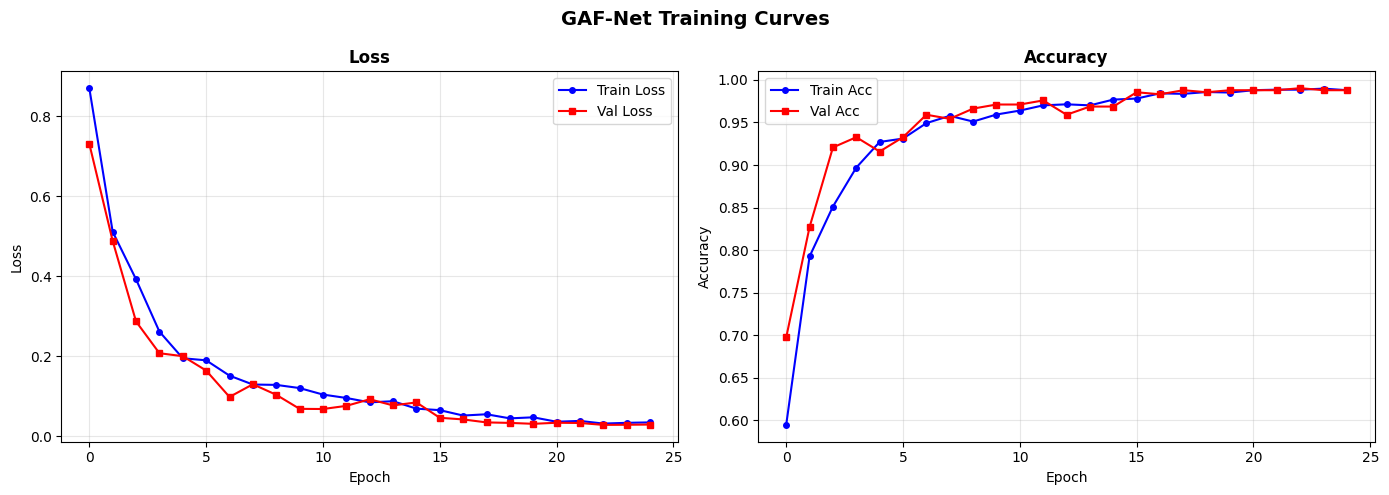

In [14]:
# Cell 14: Training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(train_losses, 'b-o', label='Train Loss', ms=4); ax1.plot(val_losses, 'r-s', label='Val Loss', ms=4)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.set_title('Loss', fontweight='bold'); ax1.legend(); ax1.grid(True, alpha=0.3)
ax2.plot(train_accs, 'b-o', label='Train Acc', ms=4); ax2.plot(val_accs, 'r-s', label='Val Acc', ms=4)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy'); ax2.set_title('Accuracy', fontweight='bold'); ax2.legend(); ax2.grid(True, alpha=0.3)
plt.suptitle('GAF-Net Training Curves', fontsize=14, fontweight='bold'); plt.tight_layout(); plt.show()

In [15]:
# Cell 15: Test evaluation
model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc='Testing'):
        images = images.to(device)
        _, preds = model(images).max(1)
        all_preds.extend(preds.cpu().numpy()); all_true.extend(labels.numpy())
test_acc = accuracy_score(all_true, all_preds)
precision, recall, f1, _ = precision_recall_fscore_support(all_true, all_preds, average='weighted')
print(f"\n{'='*50}")
print(f"GAF-Net Test Results (Potato Disease)")
print(f"{'='*50}")
print(f"Accuracy:  {test_acc:.4f}\nPrecision: {precision:.4f}\nRecall:    {recall:.4f}\nF1-Score:  {f1:.4f}")
print(f"{'='*50}")
display_names = [c.replace('_',' ') for c in CLASS_NAMES]
print('\nClassification Report:')
print(classification_report(all_true, all_preds, target_names=display_names))

Testing:   0%|          | 0/13 [00:00<?, ?it/s]


GAF-Net Test Results (Potato Disease)
Accuracy:  0.9827
Precision: 0.9828
Recall:    0.9827
F1-Score:  0.9827

Classification Report:
              precision    recall  f1-score   support

Early Blight       0.99      0.98      0.98       162
 Late Blight       0.99      0.98      0.98       141
     Healthy       0.97      1.00      0.99       102

    accuracy                           0.98       405
   macro avg       0.98      0.98      0.98       405
weighted avg       0.98      0.98      0.98       405



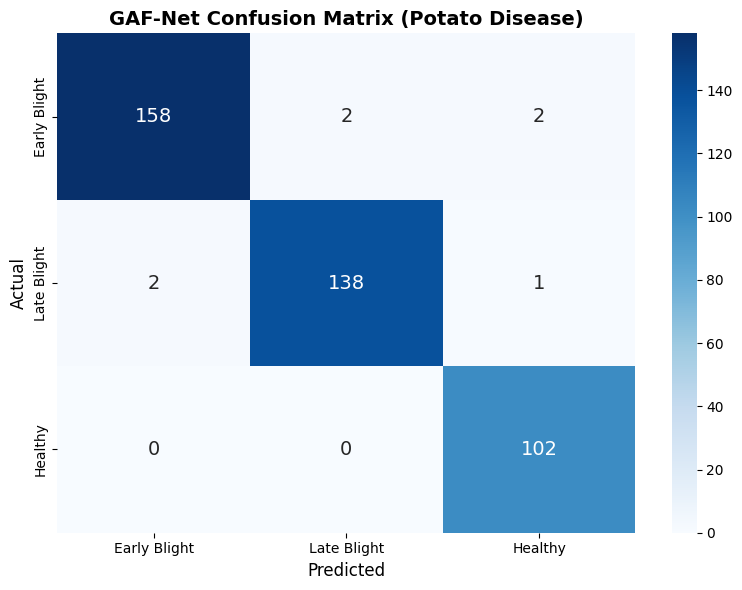

In [16]:
# Cell 16: Confusion Matrix
cm = confusion_matrix(all_true, all_preds)
dn = [c.replace('_',' ') for c in CLASS_NAMES]
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=dn, yticklabels=dn, ax=ax, annot_kws={'size':14})
ax.set_xlabel('Predicted', fontsize=12); ax.set_ylabel('Actual', fontsize=12)
ax.set_title('GAF-Net Confusion Matrix (Potato Disease)', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

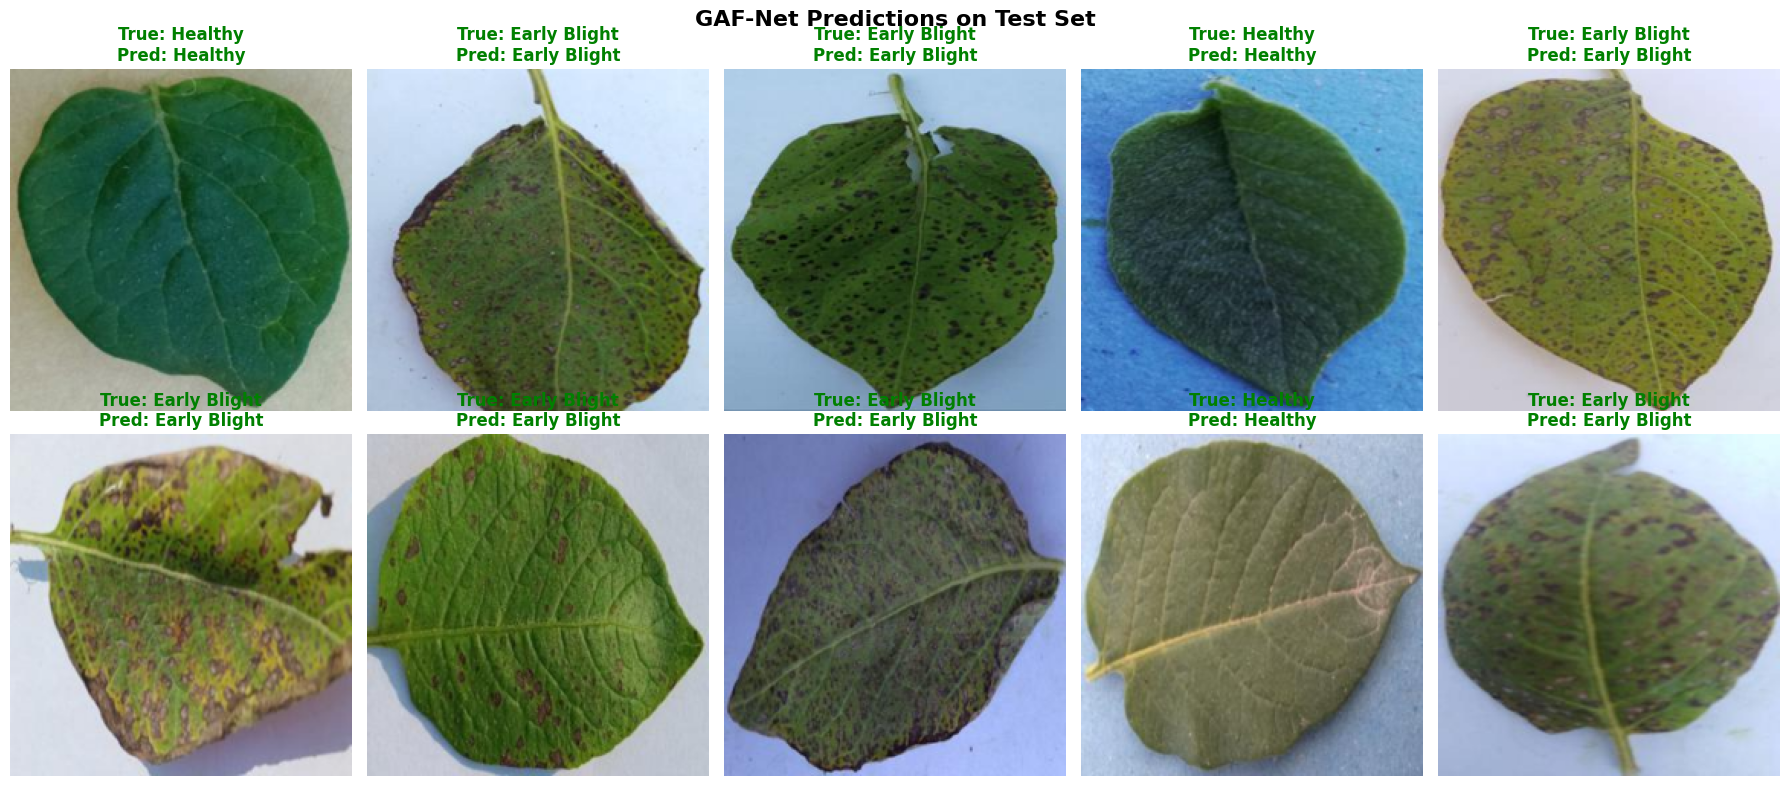

In [17]:
# Cell 17: Visualize predictions
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
fig.suptitle('GAF-Net Predictions on Test Set', fontsize=16, fontweight='bold')
dn = [c.replace('_',' ') for c in CLASS_NAMES]
model.eval()
for i, idx in enumerate(random.sample(range(len(test_ds)), 10)):
    r, c = i//5, i%5
    img, label = test_ds[idx]
    with torch.no_grad(): pred = model(img.unsqueeze(0).to(device)).argmax(1).item()
    disp = img.clone()
    for ch in range(3): disp[ch] = disp[ch]*[0.229,0.224,0.225][ch]+[0.485,0.456,0.406][ch]
    disp = disp.permute(1,2,0).clamp(0,1).numpy()
    axes[r,c].imshow(disp)
    axes[r,c].set_title(f"True: {dn[label]}\nPred: {dn[pred]}", color='green' if pred==label else 'red', fontweight='bold')
    axes[r,c].axis('off')
plt.tight_layout(); plt.show()

In [18]:
# Cell 18: Summary
print('='*60)
print('GAF-Net Architecture Summary')
print('='*60)
print(f"Dataset: Potato Disease Leaf Dataset (PLD) - {NUM_CLASSES} classes")
print(f"Classes: {', '.join(c.replace('_',' ') for c in CLASS_NAMES)}")
print(f"Key: GSConv neck + FASFF fusion + YOLOv8 backbone")
print(f"Training: {EPOCHS} epochs, patience={PATIENCE}")
print(f"Parameters: {total_params:,}")
print(f"Test Accuracy: {test_acc:.4f} | F1: {f1:.4f}")
print('='*60)

GAF-Net Architecture Summary
Dataset: Potato Disease Leaf Dataset (PLD) - 3 classes
Classes: Early Blight, Late Blight, Healthy
Key: GSConv neck + FASFF fusion + YOLOv8 backbone
Training: 25 epochs, patience=7
Parameters: 6,349,094
Test Accuracy: 0.9827 | F1: 0.9827
